In [1]:
import pickle

# Unpickle the file
with open(r"C:\Users\jalad\Downloads\Facedetection\clean_data\images.p", "rb") as f:
  images = pickle.load(f)

with open(r"C:\Users\jalad\Downloads\Facedetection\clean_data\labels.p", "rb") as f:
  labels = pickle.load(f)

In [2]:
print(images.shape)
print(labels.shape)

(600, 100, 100)
(600,)


In [3]:
set(labels)

{'Bansika', 'Bhola', 'Biswo', 'Chandan', 'Nandan', 'Priti'}

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)

In [5]:
set(labels)

{0, 1, 2, 3, 4, 5}

In [6]:
import numpy as np
n_persons = len(set(labels))
print("Number of persons: ", n_persons)
label_mapping = le.inverse_transform(np.arange(n_persons))
for i in range(len(label_mapping)):
  print(i, "-->", label_mapping[i])

Number of persons:  6
0 --> Bansika
1 --> Bhola
2 --> Biswo
3 --> Chandan
4 --> Nandan
5 --> Priti


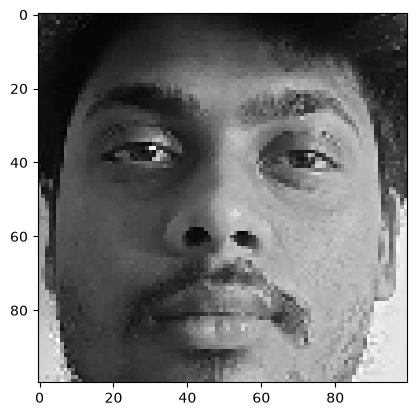

In [7]:
import matplotlib.pyplot as plt

plt.imshow(images[120], cmap=plt.get_cmap("gray"))
plt.show()

In [8]:
import cv2
def preprocessing(img):
  img = cv2.equalizeHist(img)
  img = img.reshape(100, 100, 1)
  img = img/255
  return img

In [9]:
images = np.array(list(map(preprocessing, images)))
print("Shape of Input: ", images.shape)

Shape of Input:  (600, 100, 100, 1)


In [10]:
from tensorflow.keras.utils import to_categorical

In [11]:
labels = to_categorical(labels)

In [12]:
categories = labels.shape[1]
print(categories)

6


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
# import convolution layer
from tensorflow.keras.layers import Conv2D
# import pooling layer
from tensorflow.keras.layers import MaxPooling2D
# import faltten layer
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import Adam

In [14]:
model = Sequential()
model.add(Conv2D(64, (5,5), input_shape=(100, 100, 1), activation="relu"))
model.add(Conv2D(64, (5,5), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(32, (3,3), activation="relu"))
model.add(Conv2D(32, (3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(512, activation="relu"))

model.add(Dense(6, activation="softmax"))
model.compile(Adam(learning_rate=0.0001), loss="categorical_crossentropy", metrics=['accuracy'])

C:\Users\jalad\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 64)          │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 92, 92, 64)          │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 46, 46, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 44, 44, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 42, 42, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 21, 21, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14112)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       7,225,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           3,078 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,360,774 (28.08 MB)

 Trainable params: 7,360,774 (28.08 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
h=model.fit(images,labels,validation_split=0.2,batch_size=50,epochs=10,verbose=1)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 83s 8s/step - accuracy: 1.0000 - loss: 1.3531e-05 - val_accuracy: 0.1667 - val_loss: 33.9785
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 1.0000 - loss: 1.2507e-05 - val_accuracy: 0.1667 - val_loss: 34.0532
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 104s 9s/step - accuracy: 1.0000 - loss: 1.1829e-05 - val_accuracy: 0.1667 - val_loss: 34.1102
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 151s 10s/step - accuracy: 1.0000 - loss: 1.1150e-05 - val_accuracy: 0.1667 - val_loss: 34.1583
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 90s 9s/step - accuracy: 1.0000 - loss: 1.0455e-05 - val_accuracy: 0.1667 - val_loss: 34.2104
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 91s 9s/step - accuracy: 1.0000 - loss: 9.8857e-06 - val_accuracy: 0.1667 - val_loss: 34.3040
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 94s 9s/step - accuracy: 1.0000 - loss: 9.3223e-06 - val_accuracy: 0.1667 - val_loss: 34.4013
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 91s 9s/step - accuracy: 1.0000 - loss: 8.7

In [30]:
model.save('finalmodel4.h5')

In [31]:
import cv2
k=cv2.imread(r"C:\Users\jalad\Downloads\Facedetection\images\Priti_64.jpg",cv2.IMREAD_GRAYSCALE)

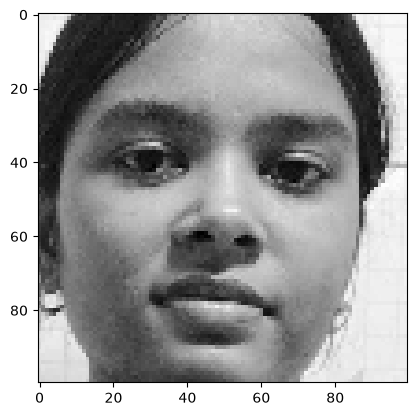

In [32]:
img=cv2.resize(k,(100,100))
#img=cv2.bitwise_not(img)
plt.imshow(img,cmap=plt.get_cmap("gray"))
plt.show()

In [33]:
img=img.reshape(1,100,100,1)
print(model.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
[[0. 0. 1. 0. 0. 0.]]


In [34]:
prediction=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


In [35]:
p=np.argmax(prediction,axis=1)
p

array([2], dtype=int64)